# Introduction à la théorie des réponses aux items

# Définition de IRT
La théorie de la réponse aux items (IRT) est un ensemble de modèles statistiques qui permettent de modéliser la probabilité de réussite d’un individu à une question. Selon le niveau de complexité, les modèles peuvent aller d'un modèle à un paramètre (1PL) au modèle à quatre paramètres (4PL).

Elle relie :
- la compétence de l’individu $i$, notée $\theta_i$
- la difficulté de l’item $j$, notée $b_j$

L’objectif est de modéliser la probabilité de réponse correcte en fonction de ces deux paramètres.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('bmh')

def logistic_function(theta, a=1, b=0, c=0, d=1): #on met les 4 paramètres pour avoir une meilleure flexibilité
    exponent = np.exp(-a * (theta - b))
    return c+(d - c) / (1 + exponent)

# Modèle de Rasch (1PL)

Le modèle de Rasch est le modèle le plus simple des 4 modèles, on considère que la probabilité de réussite ne dépend que des paramètres: 
 - $\theta_i$ la compétence de l'individu i
 - $b_j$ la difficulté de l'item j

 Sa formule :

$$P(X_i,_j=1 | \theta_i,b_j)=\frac{1}{1+e^{(-\theta_i - b_j)}}$$


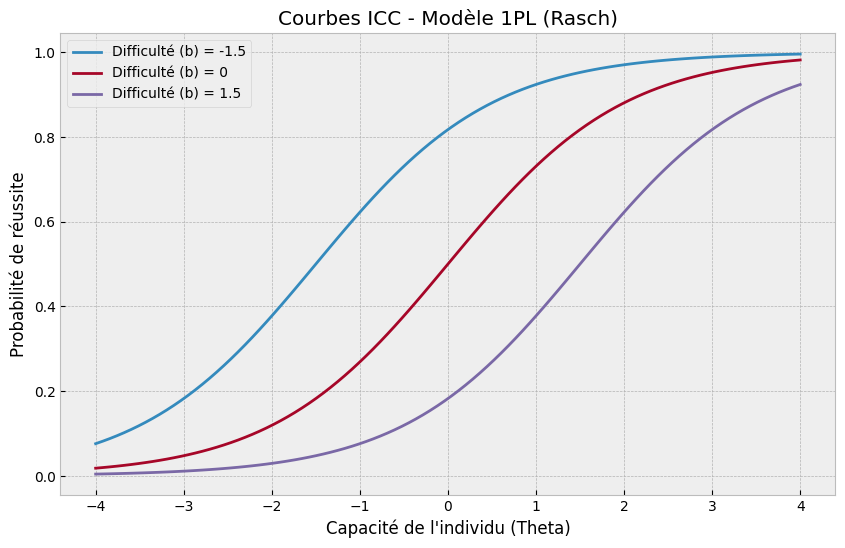

In [11]:
theta_range = np.linspace(-4, 4, 100)
difficulties = [-1.5, 0, 1.5]

plt.figure(figsize=(10, 6))
for b in difficulties:
    p = logistic_function(theta_range, b=b)
    plt.plot(theta_range, p, label=f'Difficulté (b) = {b}')

plt.title("Courbes ICC - Modèle 1PL (Rasch)")
plt.xlabel("Capacité de l'individu (Theta)")
plt.ylabel("Probabilité de réussite")
plt.legend()
plt.grid(True)
plt.show()

# Le modèle 2PL

Pour ce modèle, on rajoute un paramètre $a_j$ étant le paramètre de **discrimination** de l'item j, ce paramètre est nécéssaire pour faire le tri entre les individus, ceux qui ont une grande capacité et ceux qui ont une faible capacité.

Sa formule :

$$P(X_i,_j=1 | \theta_i,a_j,b_j)=\frac{1}{1+e^{-a_j(\theta_i - b_j)}}$$



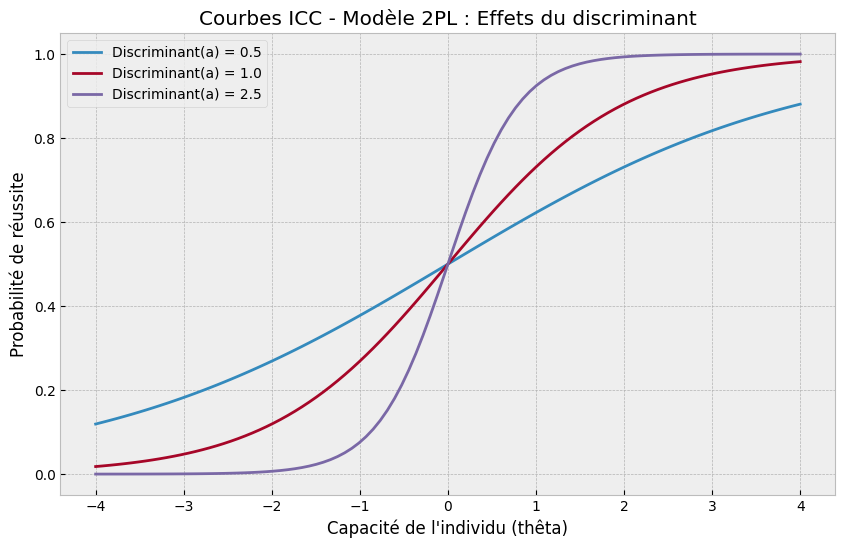

In [14]:
discriminations = [0.5, 1.0, 2.5]
b=0

plt.figure(figsize=(10,6))
for a in discriminations:
    p= logistic_function(theta_range, a=a, b=b)
    plt.plot(theta_range, p, label=f'Discriminant(a) = {a}')
    
plt.title("Courbes ICC - Modèle 2PL : Effets du discriminant")
plt.xlabel("Capacité de l'individu (thêta)")
plt.ylabel("Probabilité de réussite")
plt.legend()
plt.grid(True)
plt.show()

# Le modèle 3PL

Le modèle 3PL prend en compte un nouveau paramètre c (guessing) qui définit la probabilité pour qu'un individu de capacité basse réussit de répondre correctement à un item.

Sa formule :

$$P(X_i,_j=1 | \theta_i,a_j,b_j,c_j)=c_j+(1-c_j).\frac{1}{1+e^{-a_j(\theta_i - b_j)}}

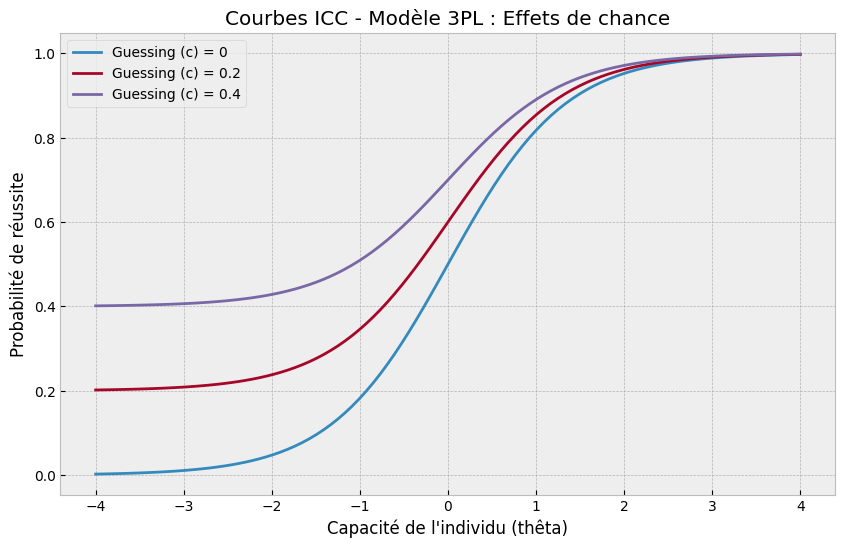

In [13]:
plt.figure(figsize = (10, 6))
c_values = [0, 0.2, 0.4]
for c in c_values:
    p = logistic_function(theta_range, a=1.5, b=0, c=c)
    plt.plot(theta_range, p, label = f'Guessing (c) = {c}')

plt.title("Courbes ICC - Modèle 3PL : Effets de chance")
plt.xlabel("Capacité de l'individu (thêta)")
plt.ylabel("Probabilité de réussite")
plt.legend()
plt.grid(True)
plt.show()

# Le modèle 4PL

On admet qu'un individu d'une grande capacité peut se tromper par inattention, fatigue ou faute de frappe, le modèle 4PPL prend en compte le paramètre d qui définit sa probabilité de réussite qui n'atteint pas 1 suit à une asymptote stagnante.

La formule : 

$$P(X_i,_j=1 |\theta_i, a_j, b_j, c_j, d_j)=(d_j - c_j).\frac{1}{1+e^{-a_j(-\theta_i-b_j)}}

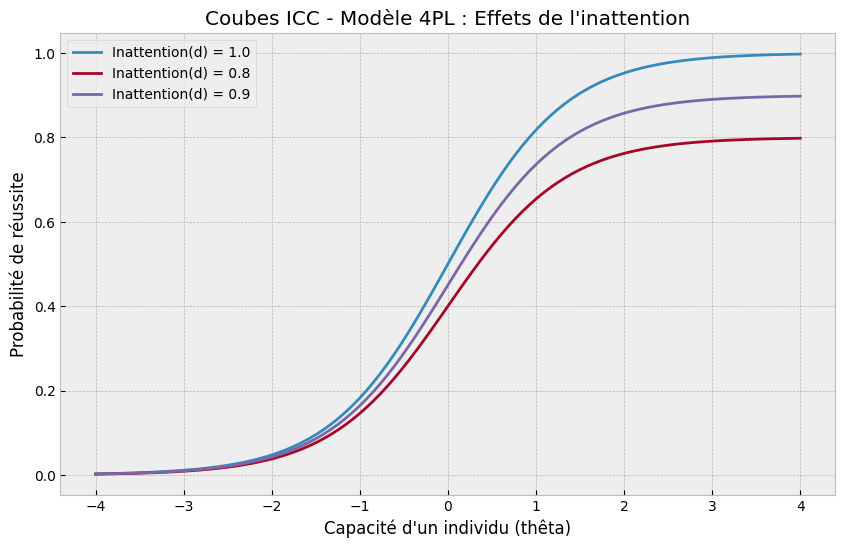

In [12]:
plt.figure(figsize = (10, 6))
d_values = [1.0, 0.8, 0.9]
for d in d_values:
    p = logistic_function(theta_range, a=1.5, b=0, d=d)
    plt.plot(theta_range, p, label=f'Inattention(d) = {d}')
plt.title("Coubes ICC - Modèle 4PL : Effets de l'inattention")
plt.xlabel("Capacité d'un individu (thêta)")
plt.ylabel("Probabilité de réussite")
plt.legend()
plt.grid(True)
plt.show()
